In [745]:
import numpy as np
import mne
from pathlib import Path

import matplotlib.pyplot as plt

from scipy.signal import resample_poly, find_peaks, welch
from scipy.stats import gaussian_kde

In [746]:
dataset_path = Path("BCI4_2a")
subject_id = 1

In [747]:
def read_subject_epochs(subject_id: int, dataset_path: Path,
                        is_train: bool = True,
                        l_freq: float = 4.0,
                        h_freq: float = 37.0,
                        tmin: float = -0.5,
                        tmax: float = 4.5):
    """
    Загружает EEG одного субъекта BCI IV 2a и возвращает:
    epochs, X, y, label_names
    """
    subject_prefix = f"A0{subject_id}"
    train_eval_label = "T" if is_train else "E"
    subject_training_data_path = dataset_path / (subject_prefix + f"{train_eval_label}.gdf")

    raw = mne.io.read_raw_gdf(subject_training_data_path, preload=True)
    bci_channels = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2',
    'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz'
    ]

    # Создаем соответствие с индексами каналов в данных
    # (если каналы называются иначе)
    if raw.ch_names[0].startswith('EEG'):
        rename_dict = dict()
        for key, value in zip(raw.ch_names[:-3], bci_channels):
            rename_dict[key] = value
        raw.rename_channels(rename_dict)
    raw.filter(l_freq, h_freq, verbose=False)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])

    raw.set_montage('standard_1020')

    events, event_dict = mne.events_from_annotations(raw)

    event_id = {
        "left": event_dict["769"],
        "right": event_dict["770"],
        "foot": event_dict["771"],
        "tongue": event_dict["772"],
    }

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose=False
    )

    X = epochs.get_data()  # (n_epochs, n_channels, n_times)
    y_raw = epochs.events[:, -1]

    label_map = {
        event_dict["769"]: 0,
        event_dict["770"]: 1,
        event_dict["771"]: 2,
        event_dict["772"]: 3,
    }
    inv_label_map = {0: "left", 1: "right", 2: "foot", 3: "tongue"}

    y = np.array([label_map[i] for i in y_raw])

    return epochs, X, y, inv_label_map

In [748]:
epochs, X, y, inv_label_map = read_subject_epochs(subject_id, dataset_path, l_freq=1, h_freq=40)

Extracting GDF parameters from BCI4_2a/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


In [749]:
X

array([[[ 7.63781568e-06,  3.15127483e-06, -3.07915555e-06, ...,
         -1.21326673e-05, -1.22171231e-05, -1.24896653e-05],
        [ 7.53149409e-06,  3.14586691e-06, -3.14981313e-06, ...,
         -8.69779633e-06, -1.11723313e-05, -1.33290237e-05],
        [ 6.38678815e-06,  1.24720962e-06, -5.29650652e-06, ...,
         -1.15289987e-05, -1.25242434e-05, -1.34075918e-05],
        ...,
        [ 4.24218161e-06, -6.89062936e-07, -5.24370921e-06, ...,
         -3.74389428e-07, -3.47889000e-06, -7.06397446e-06],
        [ 5.49240943e-06,  5.95822732e-07, -4.38301425e-06, ...,
          5.90173904e-07, -2.12950179e-06, -5.72370035e-06],
        [ 1.89501495e-06, -2.96866616e-06, -6.99007901e-06, ...,
         -1.79045309e-06, -6.58294615e-06, -1.09126148e-05]],

       [[-7.07215635e-06, -2.27951132e-06,  1.60853032e-06, ...,
          3.19835559e-06,  1.94896711e-06,  2.59135496e-06],
        [-1.13569963e-05, -7.51488324e-06, -2.81436079e-06, ...,
          7.02359197e-06,  6.74630022e

In [750]:
y

array([3, 2, 1, 0, 0, 1, 2, 3, 1, 2, 0, 0, 0, 3, 1, 1, 0, 0, 2, 0, 1, 3,
       3, 2, 0, 3, 3, 1, 3, 3, 1, 0, 1, 2, 2, 2, 3, 2, 0, 3, 1, 2, 1, 2,
       3, 1, 2, 0, 0, 0, 3, 1, 0, 2, 0, 2, 1, 3, 0, 2, 2, 0, 2, 1, 3, 3,
       3, 2, 0, 3, 1, 3, 1, 0, 2, 1, 0, 2, 2, 0, 2, 3, 3, 1, 0, 1, 3, 1,
       3, 2, 1, 1, 1, 2, 3, 0, 1, 3, 0, 2, 2, 3, 0, 0, 2, 1, 3, 3, 3, 1,
       0, 2, 1, 3, 0, 3, 2, 1, 3, 3, 0, 1, 1, 2, 3, 1, 0, 0, 3, 1, 0, 2,
       1, 1, 2, 0, 3, 2, 2, 2, 2, 0, 1, 0, 1, 0, 0, 2, 2, 1, 2, 3, 0, 3,
       0, 0, 1, 3, 2, 1, 3, 2, 3, 2, 3, 1, 1, 3, 0, 1, 1, 1, 2, 3, 0, 3,
       0, 2, 0, 3, 0, 2, 0, 1, 2, 2, 3, 0, 1, 3, 1, 2, 2, 0, 3, 1, 3, 0,
       0, 2, 2, 1, 3, 1, 1, 0, 1, 3, 3, 1, 1, 1, 1, 3, 3, 2, 3, 0, 1, 2,
       1, 0, 3, 0, 3, 0, 0, 0, 0, 2, 2, 3, 1, 2, 2, 2, 3, 2, 0, 2, 0, 3,
       1, 3, 3, 2, 3, 3, 2, 1, 3, 2, 0, 1, 1, 1, 2, 1, 3, 2, 3, 1, 2, 0,
       3, 0, 2, 3, 0, 2, 0, 1, 1, 0, 3, 0, 3, 2, 2, 0, 2, 1, 1, 0, 2, 0,
       1, 0])

In [751]:
from mne.time_frequency import psd_array_welch

In [752]:
fmin, fmax = 2, 40  # Диапазон частот
n_fft = 256
s_freq = 250


In [753]:
# freqs = np.arange(n_fft // 2 + 1, dtype=float) * (s_freq / n_fft)
# freq_mask = (freqs >= fmin) & (freqs <= fmax)
# freqs = freqs[freq_mask]
# len(freqs)

In [754]:
# psds, freqs = psd_array_welch(X, s_freq, fmin=fmin, fmax=fmax, n_fft=n_fft, n_jobs=14)
spectrum = epochs.compute_psd(method="welch", fmin=fmin, fmax=fmax, n_fft=n_fft, n_jobs=14)


Effective window size : 1.024 (s)


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   4 out of  14 | elapsed:    0.3s remaining:    0.9s
[Parallel(n_jobs=14)]: Done   7 out of  14 | elapsed:    0.4s remaining:    0.4s
[Parallel(n_jobs=14)]: Done  10 out of  14 | elapsed:    0.5s remaining:    0.2s
[Parallel(n_jobs=14)]: Done  14 out of  14 | elapsed:    1.3s finished


Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


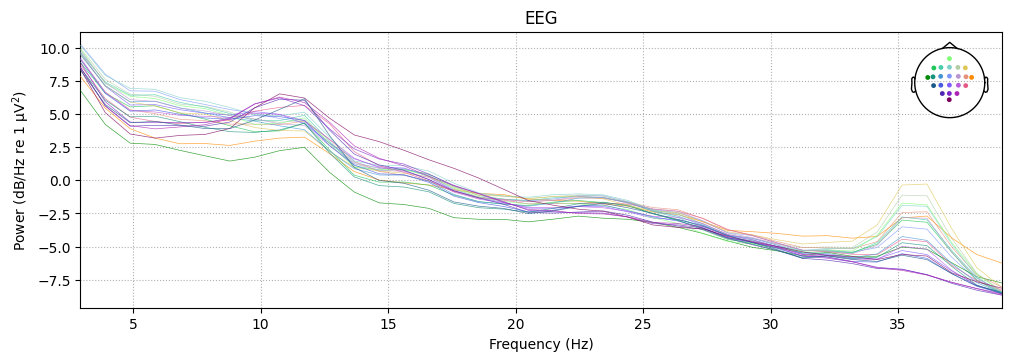

In [755]:
spectrum.plot()

In [756]:
spectrum.get_data()

array([[[4.56164912e-12, 7.51107332e-12, 8.03184902e-12, ...,
         7.30100919e-13, 1.78375207e-13, 7.91036917e-14],
        [7.98127465e-13, 5.33431756e-12, 6.00627647e-12, ...,
         6.78398918e-13, 1.80582137e-13, 4.52825893e-14],
        [4.56112871e-13, 6.17179315e-12, 8.62396972e-12, ...,
         6.25180519e-13, 1.46635747e-13, 5.49716743e-14],
        ...,
        [2.94209275e-12, 3.69110174e-12, 5.41190704e-12, ...,
         2.45391922e-13, 1.72453360e-13, 7.33330033e-14],
        [2.55727073e-12, 3.49244858e-12, 4.60858022e-12, ...,
         1.93306634e-13, 1.46420991e-13, 6.58124147e-14],
        [2.66182581e-12, 2.63258763e-12, 3.83096501e-12, ...,
         2.17509288e-13, 1.96258291e-13, 6.03089630e-14]],

       [[6.07895325e-12, 4.31173675e-12, 3.88139691e-12, ...,
         3.05317307e-13, 1.52065698e-13, 1.76154502e-13],
        [1.06986196e-11, 4.42678877e-12, 3.92854715e-12, ...,
         3.19493981e-13, 8.06035599e-14, 1.52050428e-13],
        [9.65862583e-12, 

In [757]:
spectrum.freqs

array([ 2.9296875,  3.90625  ,  4.8828125,  5.859375 ,  6.8359375,
        7.8125   ,  8.7890625,  9.765625 , 10.7421875, 11.71875  ,
       12.6953125, 13.671875 , 14.6484375, 15.625    , 16.6015625,
       17.578125 , 18.5546875, 19.53125  , 20.5078125, 21.484375 ,
       22.4609375, 23.4375   , 24.4140625, 25.390625 , 26.3671875,
       27.34375  , 28.3203125, 29.296875 , 30.2734375, 31.25     ,
       32.2265625, 33.203125 , 34.1796875, 35.15625  , 36.1328125,
       37.109375 , 38.0859375, 39.0625   ])

In [758]:
from scipy.stats import ttest_ind
from typing import Dict, Tuple

In [759]:
def group_by_bands(spectrum: mne.time_frequency.EpochsSpectrum, bands: Dict[str, Tuple[float, float]]):
    band_powers = dict()
    for band_name, (f_min, f_max) in bands.items():
        band_powers[band_name] = np.mean(spectrum.get_data(fmin=f_min, fmax=f_max), axis=2)
    
    return band_powers

In [760]:
bands = {'Delta (0-4 Hz)': (0, 4), 'Theta (4-8 Hz)': (4, 8),
         'Alpha (8-12 Hz)': (8, 12), 'Beta (12-30 Hz)': (12, 30),
         'Gamma (30-45 Hz)': (30, 45)}

In [761]:
band_powers_left = group_by_bands(spectrum['left'], bands)
band_powers_right = group_by_bands(spectrum['foot'], bands)

In [762]:
band_powers_left

{'Delta (0-4 Hz)': array([[1.37456786e-11, 1.33700570e-11, 1.31967188e-11, ...,
         6.56964087e-12, 5.94776284e-12, 7.57306080e-12],
        [1.09488288e-11, 7.26096772e-12, 1.10276142e-11, ...,
         8.50155254e-12, 7.91550733e-12, 7.09871803e-12],
        [1.04479080e-11, 6.33961464e-12, 6.02981995e-12, ...,
         2.55077766e-12, 2.27341074e-12, 2.80404369e-12],
        ...,
        [5.04615901e-12, 3.70334398e-12, 3.41563270e-12, ...,
         2.20102597e-12, 2.52283422e-12, 2.98288642e-12],
        [3.98082963e-12, 4.13645200e-12, 5.29987270e-12, ...,
         6.52887999e-12, 5.42076995e-12, 5.47103724e-12],
        [4.54750748e-11, 2.13104860e-11, 2.00205647e-11, ...,
         7.72203408e-12, 6.91483884e-12, 7.87941158e-12]], shape=(72, 22)),
 'Theta (4-8 Hz)': array([[6.12249502e-12, 5.98466673e-12, 6.30362945e-12, ...,
         7.08435042e-12, 5.88553118e-12, 4.04905950e-12],
        [4.03727694e-12, 2.58639784e-12, 3.20222865e-12, ...,
         1.48761613e-12, 1.2259

In [763]:
def statistical_test(band_powers_1, band_powers_2, stat_test_func, stat_test_func_kwargs=dict()):
    result_dict = dict()
    p_value_dict = dict()
    statistic_dict = dict()

    for (band, epoch_channel_power_array_1), epoch_channel_power_array_2 in zip(band_powers_1.items(), band_powers_2.values()):
        channel_epoch_power_array_1 = np.swapaxes(epoch_channel_power_array_1, 0, 1)
        channel_epoch_power_array_2 = np.swapaxes(epoch_channel_power_array_2, 0, 1)
        result_dict[band] = list()
        p_value_dict[band] = list()
        statistic_dict[band] = list()
        for channel, (epoch_power_array_1, epoch_power_array_2) in enumerate(zip(channel_epoch_power_array_1, channel_epoch_power_array_2)):
            result = ttest_ind(epoch_power_array_1, epoch_power_array_2, **stat_test_func_kwargs)
            result_dict[band].append(result)
            p_value_dict[band].append(result.pvalue)
            statistic_dict[band].append(result.statistic)
            if result.pvalue < 0.05:
                 print(result.pvalue, band)
        result_dict[band] = np.array(result_dict[band])
        p_value_dict[band] = np.array(p_value_dict[band])
        statistic_dict[band] = np.array(statistic_dict[band])

    return result_dict, p_value_dict, statistic_dict

In [764]:
result_dict, p_value_dict, statistic_dict = statistical_test(band_powers_left, band_powers_right, stat_test_func=ttest_ind, stat_test_func_kwargs = {"equal_var": False})

0.04172696162337394 Delta (0-4 Hz)
0.035772779179034965 Delta (0-4 Hz)
0.031380450526203356 Alpha (8-12 Hz)
0.0057629175583894104 Alpha (8-12 Hz)
0.0005931986063920455 Alpha (8-12 Hz)
0.013250695851094974 Alpha (8-12 Hz)
7.798891663318646e-06 Alpha (8-12 Hz)
0.004155156476419888 Alpha (8-12 Hz)
0.04768032568496613 Alpha (8-12 Hz)
0.01719364755164561 Alpha (8-12 Hz)
0.0002607441439113022 Alpha (8-12 Hz)
0.00035796122278337384 Alpha (8-12 Hz)
0.003810688356224036 Alpha (8-12 Hz)
0.000950192488889485 Alpha (8-12 Hz)
0.0032113822594910684 Alpha (8-12 Hz)
0.013050127466082763 Beta (12-30 Hz)
0.02918550800638445 Beta (12-30 Hz)
0.02855879137139422 Beta (12-30 Hz)
0.0009497525501753283 Beta (12-30 Hz)
1.6868591305893984e-05 Beta (12-30 Hz)
0.0043175722167123985 Beta (12-30 Hz)
0.017019061495201066 Beta (12-30 Hz)
6.15868950206339e-05 Beta (12-30 Hz)


In [765]:
epochs.info["dig"]
pass

In [766]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

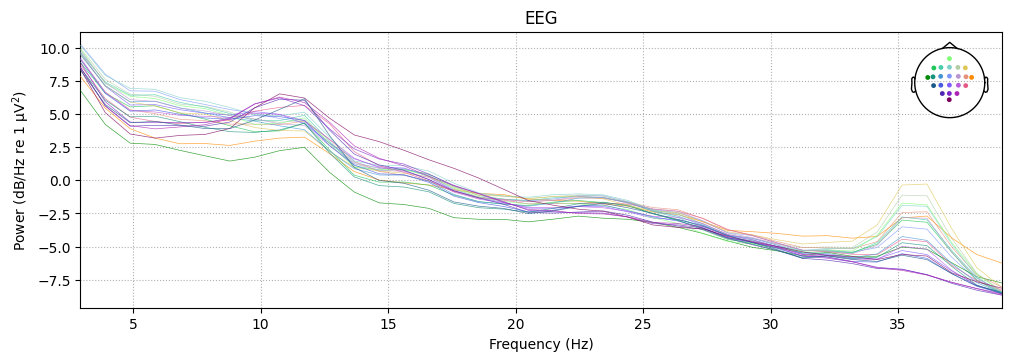

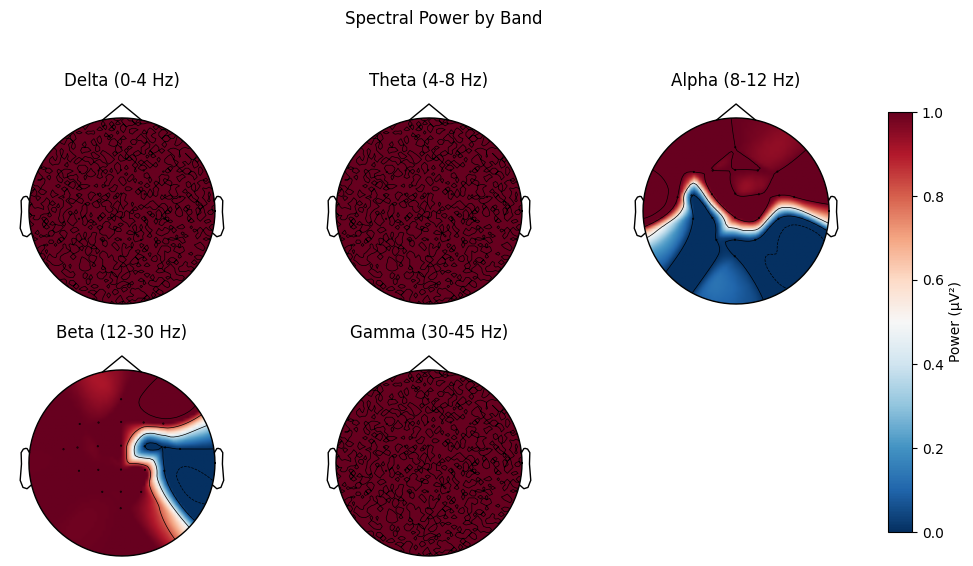

In [767]:
def plot_stattest_result(data):
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 3, figure=fig)
    gs.update(right=0.85)  # место под colorbar

    # Единый vmin/vmax для сравнения
    all_vals = np.concatenate([np.atleast_1d(v).ravel() for v in data.values()])
    vlim = (np.percentile(all_vals, 5), np.percentile(all_vals, 95))
    vlim = (0, 1)


    for idx, (name, _) in enumerate(bands.items()):
        ax = fig.add_subplot(gs[idx // 3, idx % 3])
        data[name] = np.array(list(map(lambda x: 0 if x < 0.005 else 1, data[name])))
        im, cntr = mne.viz.plot_topomap(
            data[name], pos=epochs.info, axes=ax, show=False,
            vlim=vlim, cmap='RdBu_r'
        )
        ax.set_title(name)

    # Общий colorbar
    cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Power (µV²)')
    plt.suptitle('Spectral Power by Band', y=1.02)
    plt.show()

plot_stattest_result(p_value_dict)

In [768]:
from scipy.stats import mannwhitneyu

0.04167505405023131 Delta (0-4 Hz)
0.03562857228616989 Delta (0-4 Hz)
0.03132766175298711 Alpha (8-12 Hz)
0.005758594032612226 Alpha (8-12 Hz)
0.0005768278461787769 Alpha (8-12 Hz)
0.013146396524490563 Alpha (8-12 Hz)
6.558461660175712e-06 Alpha (8-12 Hz)
0.004009864409186391 Alpha (8-12 Hz)
0.04726270216299955 Alpha (8-12 Hz)
0.016903678427283436 Alpha (8-12 Hz)
0.0002395987061524866 Alpha (8-12 Hz)
0.00033338518006522554 Alpha (8-12 Hz)
0.0036973633798898283 Alpha (8-12 Hz)
0.0009042307593825176 Alpha (8-12 Hz)
0.0031856239881701783 Alpha (8-12 Hz)
0.013048527919862652 Beta (12-30 Hz)
0.029178497337565588 Beta (12-30 Hz)
0.028535347415213293 Beta (12-30 Hz)
0.0009494549143985165 Beta (12-30 Hz)
1.6823588419283277e-05 Beta (12-30 Hz)
0.004263051022140192 Beta (12-30 Hz)
0.01701461693470612 Beta (12-30 Hz)
6.156018109251483e-05 Beta (12-30 Hz)


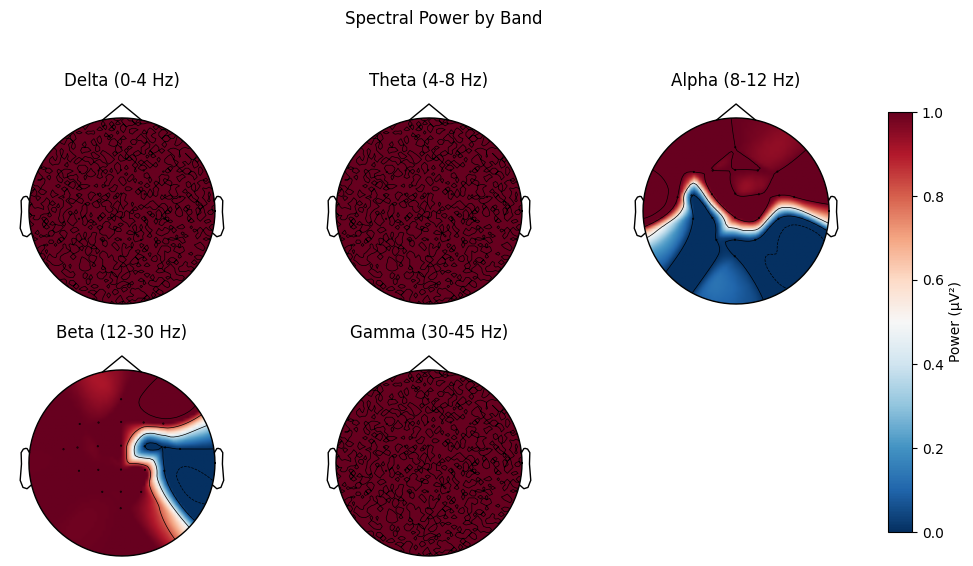

In [769]:
result_dict, p_value_dict, statistic_dict = statistical_test(band_powers_left, band_powers_right, stat_test_func=mannwhitneyu)
plot_stattest_result(p_value_dict)

In [770]:
adj = mne.channels.find_ch_adjacency(epochs.info, 'eeg')

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 22


In [771]:
adj

(<Compressed Sparse Row sparse array of dtype 'int64'
 	with 128 stored elements and shape (22, 22)>,
 ['Fz',
  'FC3',
  'FC1',
  'FCz',
  'FC2',
  'FC4',
  'C5',
  'C3',
  'C1',
  'Cz',
  'C2',
  'C4',
  'C6',
  'CP3',
  'CP1',
  'CPz',
  'CP2',
  'CP4',
  'P1',
  'Pz',
  'P2',
  'POz'])

In [772]:
print(adj[0].toarray()[4])

[1 0 0 1 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]


In [773]:
left_sample, right_sample = spectrum['left'], spectrum['right']

In [774]:
left_sample.shape

(72, 22, 38)

In [775]:
time_adjacency = mne.stats.combine_adjacency(
    left_sample.shape[2], adj[0]
)

In [776]:
time_adjacency

<COOrdinate sparse array of dtype 'float64'
	with 6492 stored elements and shape (836, 836)>

In [777]:
print(time_adjacency[88])

<COOrdinate sparse array of dtype 'float64'
	with 8 stored elements and shape (836,)>
  Coords	Values
  (66,)	1.0
  (110,)	1.0
  (89,)	1.0
  (90,)	1.0
  (91,)	1.0
  (92,)	1.0
  (93,)	1.0
  (88,)	1.0


In [778]:
left_sample.data

array([[[1.63681261e-11, 1.11232311e-11, 5.27168385e-12, ...,
         3.77419295e-13, 2.01872987e-13, 9.96262063e-14],
        [1.67258589e-11, 1.00142551e-11, 5.04387930e-12, ...,
         4.33414843e-13, 1.66038979e-13, 4.32542058e-14],
        [1.56684255e-11, 1.07250122e-11, 5.05478455e-12, ...,
         3.63627113e-13, 1.14792968e-13, 5.06411709e-14],
        ...,
        [7.18714919e-12, 5.95213255e-12, 2.80981054e-12, ...,
         9.96487382e-14, 3.91194001e-14, 3.66893295e-14],
        [6.47504236e-12, 5.42048331e-12, 2.41041174e-12, ...,
         8.47589412e-14, 4.16142092e-14, 4.09366477e-14],
        [8.29839203e-12, 6.84772958e-12, 2.50144977e-12, ...,
         9.15151060e-14, 2.50652791e-14, 5.56794804e-14]],

       [[8.60213970e-12, 1.32955179e-11, 4.38219746e-12, ...,
         6.84628401e-13, 2.20545029e-13, 4.65820613e-14],
        [7.11692406e-12, 7.40501138e-12, 2.43632265e-12, ...,
         5.57433739e-13, 2.54706048e-13, 1.00270300e-13],
        [1.06764975e-11, 

In [779]:
from matplotlib.pylab import axes
left_sample_reshaped = left_sample.data.transpose(0, 2, 1)
right_sample_reshaped = right_sample.data.transpose(0, 2, 1)
left_sample_reshaped.shape

(72, 38, 22)

In [780]:
f_thresh=dict(start=0, step=0.2)

In [794]:
import scipy
p_unc = 0.005
dfn = 1  # степени свободы числителя (между группами) = количество групп - 1
dfd = (left_sample_reshaped.shape[0] + right_sample_reshaped.shape[0] - 2)  # внутригрупповые степени свободы
f_thresh = scipy.stats.f.ppf(1 - p_unc, dfn, dfd)
f_thresh

np.float64(8.131394692126236)

In [795]:
F_obs, clusters, cluster_pv, H0 = mne.stats.permutation_cluster_test([left_sample_reshaped, right_sample_reshaped], threshold=f_thresh, n_permutations=4000,
                                   adjacency=time_adjacency, seed = 42, n_jobs = 5, check_disjoint=True)
#significant_points = cluster_pv.reshape(F_obs.shape).T < 0.05
#print(str(significant_points.sum()) + " points selected by TFCE ...")

stat_fun(H1): min=6.623146480352782e-06 max=8.15814062498457
No disjoint adjacency sets found
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/3999 [00:00<?,       ?it/s]

In [796]:
print(min(cluster_pv))

0.65125


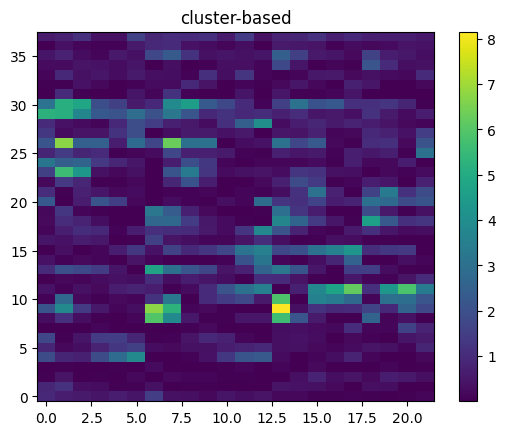

In [784]:
plt.imshow(F_obs, origin='lower', aspect='auto')
plt.colorbar()
plt.title('cluster-based')
plt.show()

In [785]:
choosen = []
for i, val in enumerate(cluster_pv):
    if val < 0.05: choosen.append((i, val))

choosen

[]

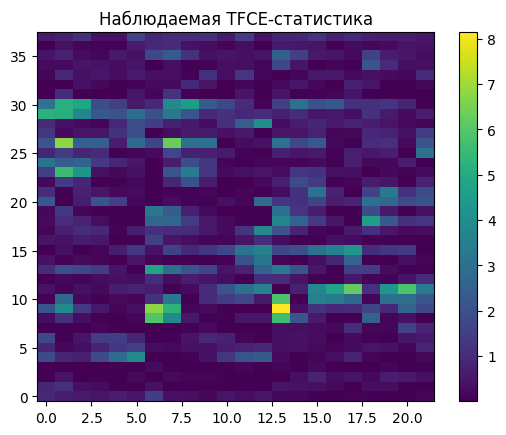

In [786]:
import matplotlib.pyplot as plt
plt.imshow(F_obs, origin='lower', aspect='auto')
plt.colorbar()
plt.title("Наблюдаемая TFCE-статистика")
plt.show()

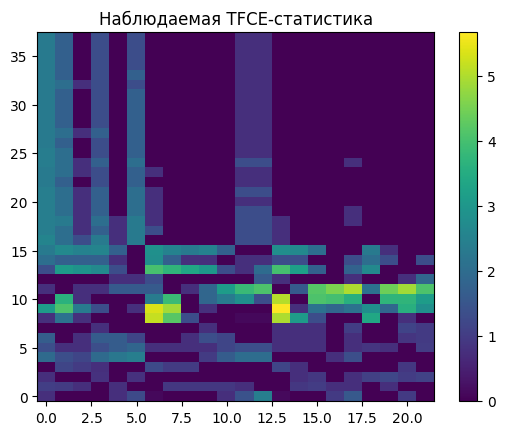

In [787]:
plt.imshow(F_obs1, origin='lower', aspect='auto')
plt.colorbar()
plt.title("Наблюдаемая TFCE-статистика")
plt.show()

In [788]:
choosen = []
for i, val in enumerate(cluster_pv1):
    if val < 0.95: choosen.append((i, val))

choosen

[(182, np.float64(0.8265)),
 (183, np.float64(0.93075)),
 (189, np.float64(0.855)),
 (199, np.float64(0.938)),
 (204, np.float64(0.8035)),
 (205, np.float64(0.86375)),
 (211, np.float64(0.765)),
 (233, np.float64(0.847)),
 (235, np.float64(0.93875)),
 (236, np.float64(0.94625)),
 (254, np.float64(0.93875)),
 (257, np.float64(0.93225)),
 (258, np.float64(0.895)),
 (259, np.float64(0.85475)),
 (261, np.float64(0.91075)),
 (262, np.float64(0.8635)),
 (263, np.float64(0.93875)),
 (292, np.float64(0.9425)),
 (299, np.float64(0.9455))]

In [789]:
cluster_pv1

array([1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 0.99625, 1.     ,
       1.     , 1.     , 1.     , 0.99975, 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 0.999  , 1.     , 1.     ,
       0.999  , 0.998  , 0.99625, 1.     , 1.     , 1.     , 1.     ,
       0.99975, 0.99

In [790]:
clusters[192]

IndexError: list index out of range

In [ ]:
clusters[1]

(array([0]), array([1]))

In [ ]:
set([17,  5,  9, 10, 11, 12, 15, 16, 17, 19, 20, 21,  5, 10, 11, 12, 15,
        16, 17, 20, 10, 11, 12, 16, 17, 20])

{5, 9, 10, 11, 12, 15, 16, 17, 19, 20, 21}